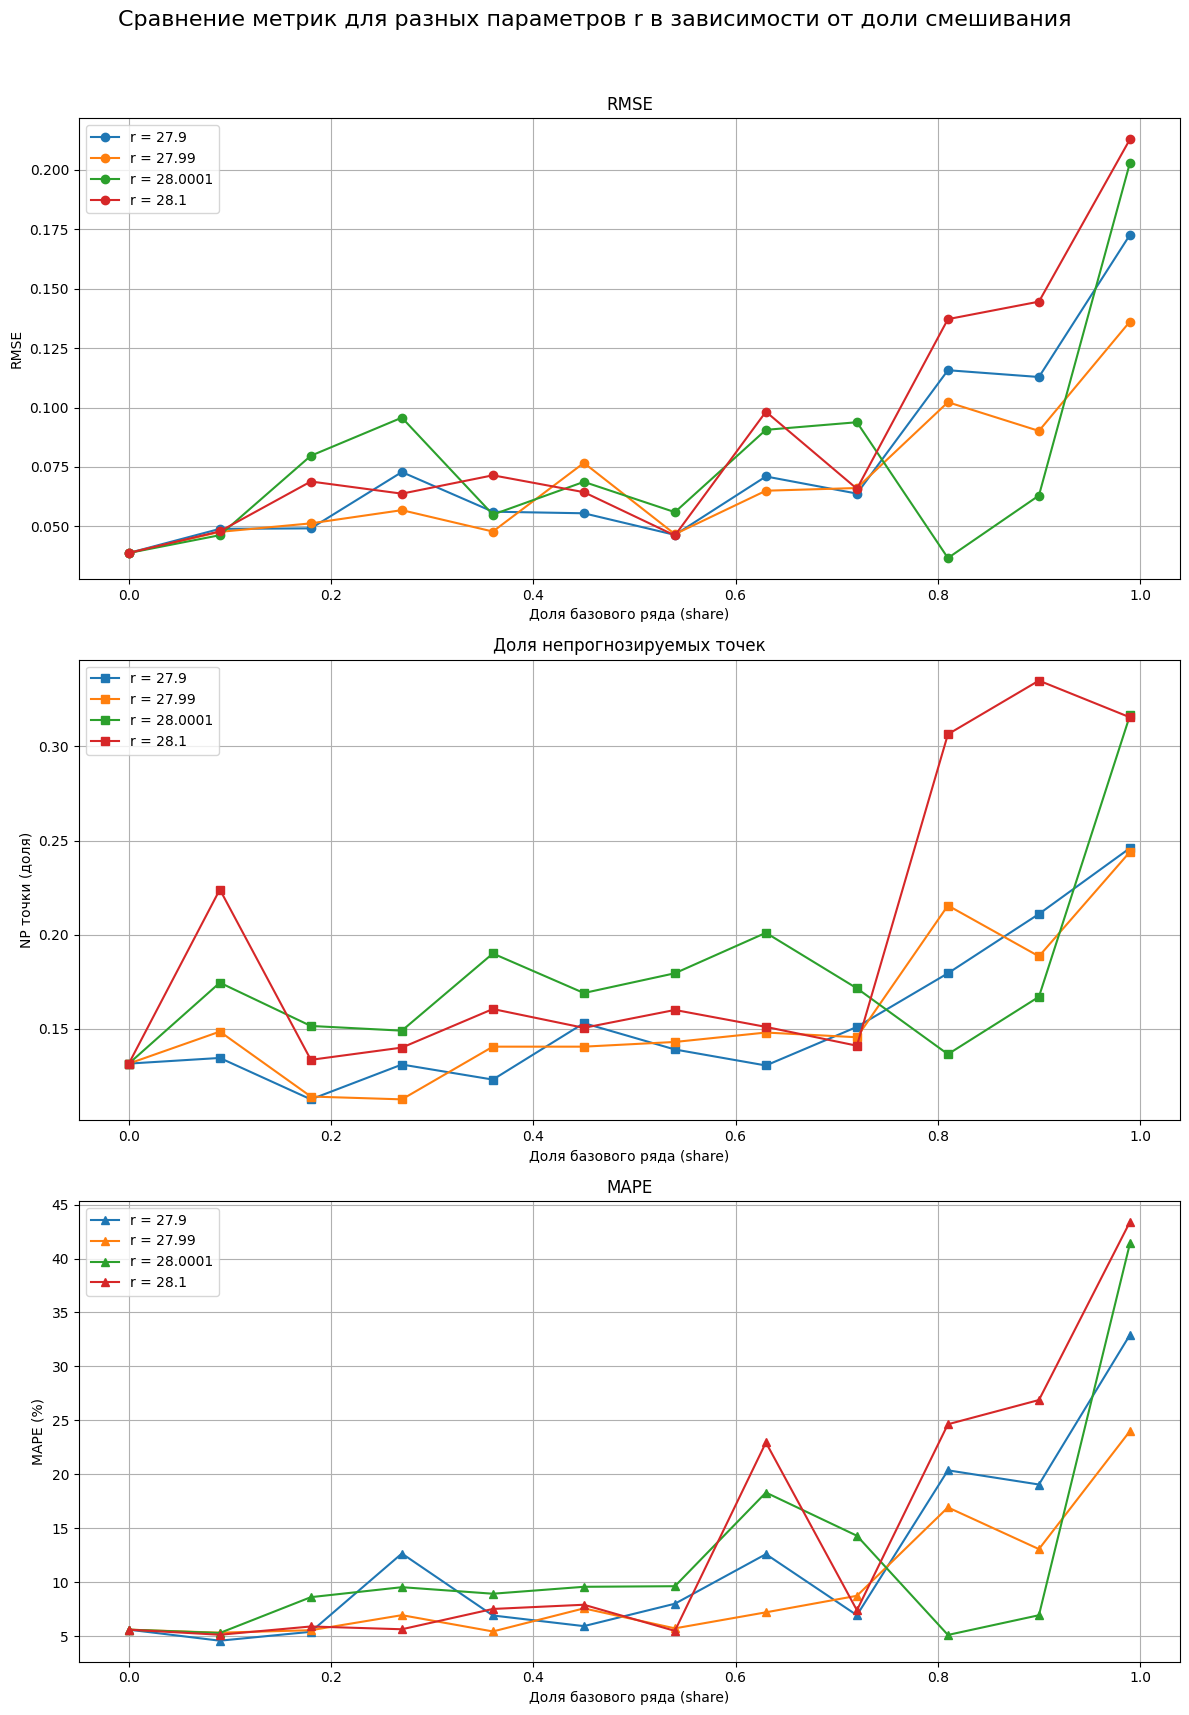

Создан один файл: 'combined_metrics_comparison.png'


In [3]:
import pandas as pd
import matplotlib.pyplot as plt

# Загрузка данных
df = pd.read_csv('share_experiment.txt', header=None)

# Группировка по первому столбцу (смещению от r=28)
grouped = df.groupby(0)

# 1. Создаем фигуру БЕЗ sharex=True
# <<< ИЗМЕНЕНИЕ: убран параметр sharex=True
fig, axes = plt.subplots(3, 1, figsize=(12, 18))

# Добавляем общий заголовок для всей фигуры
fig.suptitle('Сравнение метрик для разных параметров r в зависимости от доли смешивания', fontsize=16)

# --- Подграфик 0: RMSE ---
for name, group in grouped:
    group_sorted = group.sort_values(by=1)
    axes[0].plot(group_sorted[1], group_sorted[3], 'o-', label=f'r = {name + 28}')

axes[0].set_ylabel('RMSE')
axes[0].set_title('RMSE')
axes[0].legend()
axes[0].grid(True)
# <<< ИЗМЕНЕНИЕ: Добавлена подпись оси X для первого графика
axes[0].set_xlabel('Доля базового ряда (share)')

# --- Подграфик 1: NP точки (доля) ---
for name, group in grouped:
    group_sorted = group.sort_values(by=1)
    axes[1].plot(group_sorted[1], group_sorted[4], 's-', label=f'r = {name + 28}')

axes[1].set_ylabel('NP точки (доля)')
axes[1].set_title('Доля непрогнозируемых точек')
axes[1].legend()
axes[1].grid(True)
# <<< ИЗМЕНЕНИЕ: Добавлена подпись оси X для второго графика
axes[1].set_xlabel('Доля базового ряда (share)')

# --- Подграфик 2: MAPE (%) ---
for name, group in grouped:
    group_sorted = group.sort_values(by=1)
    axes[2].plot(group_sorted[1], group_sorted[5] * 100, '^-', label=f'r = {name + 28}')

axes[2].set_ylabel('MAPE (%)')
axes[2].set_title('MAPE')
axes[2].legend()
axes[2].grid(True)
# Подпись для третьего графика уже была, оставляем ее
axes[2].set_xlabel('Доля базового ряда (share)')

# Автоматически подгоняем отступы
plt.tight_layout(rect=[0, 0.03, 1, 0.96])

# Сохраняем ВСЮ фигуру в ОДИН файл
plt.savefig('combined_metrics_comparison.png', dpi=150)
plt.show()

print("Создан один файл: 'combined_metrics_comparison.png'")